In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../../dmri/utils/pyloric.mplstyle")


In [3]:
from dmri.train.utils import load_cfg, load_checkpoint

#checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated_all_3_6_8_128_model_prior")
graphdef, params,  state = nnx.split(model, nnx.Param,  ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, state)
sim_type = model.tokenizer.simulator
model.eval()

In [6]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

folder_name = "data"
data, affine = load_nifti(f"../../data/{folder_name}/data.nii.gz")
brain_mask, _ = load_nifti(f"../../data/{folder_name}/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs(f"../../data/{folder_name}/bvals", f"../../data/{folder_name}/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, None)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)


idx = np.argsort(bvals)

bvals = bvals[idx]
bvecs = bvecs[idx]
data_norm = data_norm[...,idx]

full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]
full_data_flat_in_brain = np.nan_to_num(full_data_flat_in_brain, nan=0, posinf=0, neginf=0)

exclude_outliers = np.quantile(full_data_flat_in_brain, 0.999)
full_data_flat_in_brain = np.clip(full_data_flat_in_brain, 0, exclude_outliers)

acq = acquisition_scheme(np.array(bvals), np.array(bvecs))


/tmp/ipykernel_3317487/1353376310.py:19: RuntimeWarning: divide by zero encountered in divide
  data_norm = data / S0[..., None]
/tmp/ipykernel_3317487/1353376310.py:19: RuntimeWarning: invalid value encountered in divide
  data_norm = data / S0[..., None]


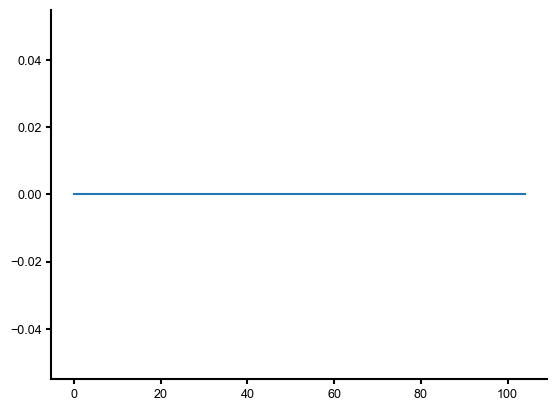

In [7]:
plt.plot(data_norm[0,0,0,:])

In [8]:
color1 = "#2596be"
color2 = "#be4d25"

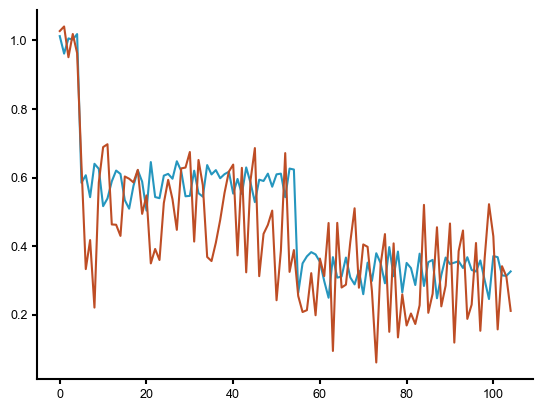

In [9]:
x_0 = full_data_flat_in_brain[10_173]
x_1 = full_data_flat_in_brain[50_000]
plt.plot(x_0, color=color1)
plt.plot(x_1, color=color2)

In [10]:
m1 = jnp.array([True, True, True, True] + [False]*6 + [True, False])
m2 = jnp.array([True] + [False]*6 + [True]*3 + [True, False])
#m1 = jnp.array([True] + [False]*3 + [True] + [False]*2 + [True] + [False]*2 + [True, False])
#m1 = jnp.array([True]*11 + [False])

In [11]:
m2.shape

(12,)

In [34]:
from functools import partial
sample_fn1 = jax.jit(jax.vmap(partial(model.sample_theta, t_min=5e-4, model_mask=m1), in_axes=(0,None, None)))
sample_fn2 = jax.jit(jax.vmap(partial(model.sample_theta, t_min=5e-4, model_mask=m2, num_steps=128), in_axes=(0,None, None)))

In [24]:
thetas_post1 = sample_fn1(jax.random.split(jax.random.key(0), 100_000), acq, x_0)
thetas_post2 = sample_fn1(jax.random.split(jax.random.key(0), 100_000), acq, x_1)

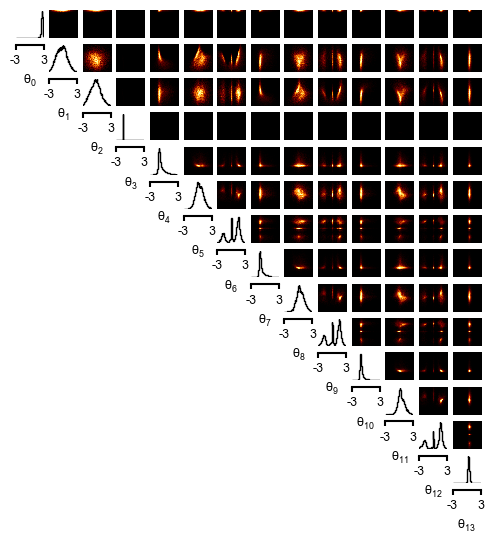

In [30]:
#import sbi
from sbi.analysis.plot import pairplot
theta_mask = sim_type.theta_mask(m1)
fig, axes = pairplot([thetas_post1[:,theta_mask]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[rf'$\theta_{{{i}}}$'  for i in range(int(sum(theta_mask)))], figsize=(6, 6), upper_kwargs=[dict(mpl_kwargs=dict(cmap="afmhot", origin="lower", aspect="auto"),np_hist_kwargs ={"bins": 100, "density": False},)],upper="hist", diag_kwargs=[dict(mpl_kwargs=dict(color="black", bins=200 ))])
for i in range(len(axes)):
    axes[i,i].set_xticks([-3,3])
fig.savefig("all_model_illustrative_post1_m1_b3s.svg")

In [35]:
thetas_post1_m2 = sample_fn2(jax.random.split(jax.random.key(0), 100_000), acq, x_0)
thetas_post2_m2 = sample_fn2(jax.random.split(jax.random.key(0), 100_000), acq, x_1)

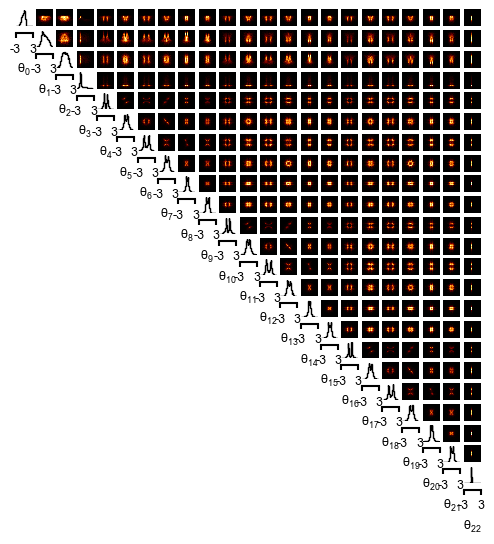

In [36]:
#import sbi
from sbi.analysis.plot import pairplot
theta_mask = sim_type.theta_mask(m2)
fig, axes = pairplot([thetas_post2_m2[:,theta_mask]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[rf'$\theta_{{{i}}}$'  for i in range(int(sum(theta_mask)))], figsize=(6, 6), upper_kwargs=[dict(mpl_kwargs=dict(cmap="afmhot", origin="lower", aspect="auto"),np_hist_kwargs ={"bins": 100, "density": False},)],upper="hist", diag_kwargs=[dict(mpl_kwargs=dict(color="black", bins=200 ))])
for i in range(len(axes)):
    axes[i,i].set_xticks([-3,3])
fig.savefig("all_model_illustrative_b3t.png", dpi=300)
fig.savefig("all_model_illustrative_b3t.svg")

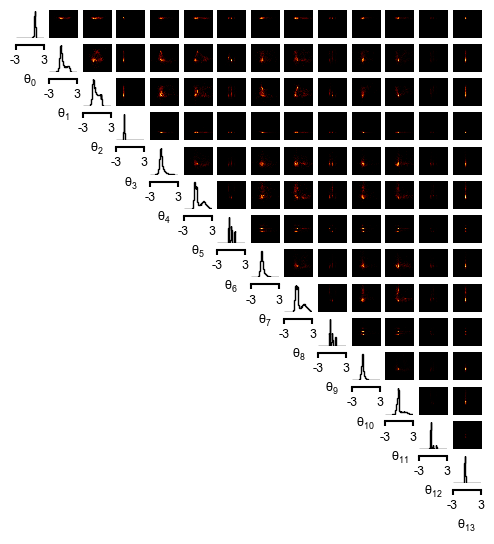

In [28]:
#import sbi
from sbi.analysis.plot import pairplot
theta_mask = sim_type.theta_mask(m1)
fig, axes = pairplot([thetas_post2_m1[:,theta_mask]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[rf'$\theta_{{{i}}}$'  for i in range(int(sum(theta_mask)))], figsize=(6, 6), upper_kwargs=[dict(mpl_kwargs=dict(cmap="afmhot", origin="lower", aspect="auto"),np_hist_kwargs ={"bins": 500, "density": False},)],upper="hist", diag_kwargs=[dict(mpl_kwargs=dict(color="black", bins=200))])
for i in range(len(axes)):
    axes[i,i].set_xticks([-3,3])
fig.savefig("all_model_illustrative_post2_m1_b3s.png", dpi=300)
fig.savefig("all_model_illustrative_post2_m1_b3s.svg")

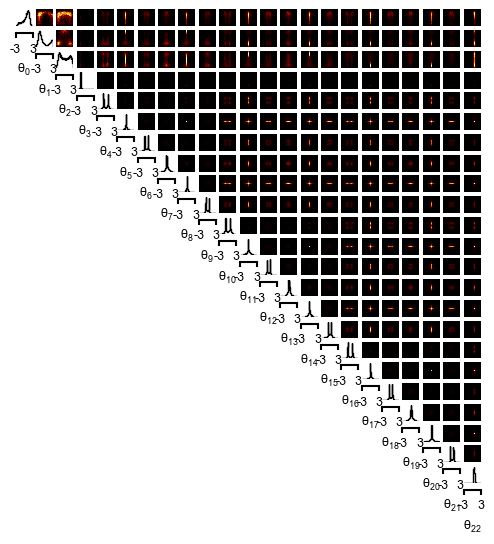

In [30]:
#import sbi
from sbi.analysis.plot import pairplot
theta_mask = sim_type.theta_mask(m2)
fig, axes = pairplot([thetas_post1[:,theta_mask]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[rf'$\theta_{{{i}}}$'  for i in range(int(sum(theta_mask)))], figsize=(6, 6), upper_kwargs=[dict(mpl_kwargs=dict(cmap="afmhot", origin="lower", aspect="auto"),np_hist_kwargs ={"bins": 100, "density": False},)],upper="hist", diag_kwargs=[dict(mpl_kwargs=dict(color="black", bins=200 ))])
for i in range(len(axes)):
    axes[i,i].set_xticks([-3,3])
fig.savefig("all_model_illustrative_post1_m2_b3s.png", dpi=300)
fig.savefig("all_model_illustrative_post1_m2_b3s.svg")

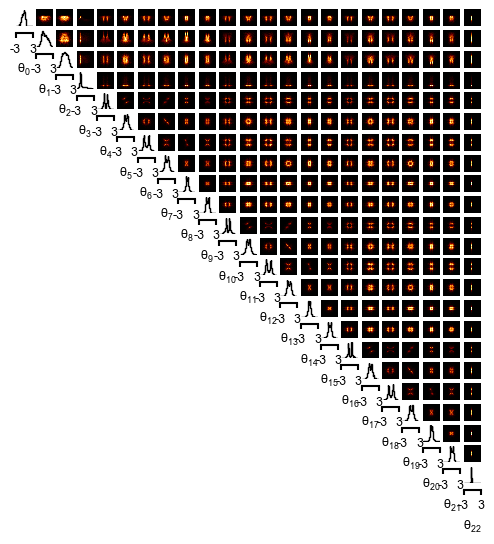

In [32]:
#import sbi
from sbi.analysis.plot import pairplot
theta_mask = sim_type.theta_mask(m2)
fig, axes = pairplot([thetas_post2[:,theta_mask]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[rf'$\theta_{{{i}}}$'  for i in range(int(sum(theta_mask)))], figsize=(6, 6), upper_kwargs=[dict(mpl_kwargs=dict(cmap="afmhot", origin="lower", aspect="auto"),np_hist_kwargs ={"bins": 100, "density": False},)],upper="hist", diag_kwargs=[dict(mpl_kwargs=dict(color="black", bins=200 ))])
for i in range(len(axes)):
    axes[i,i].set_xticks([-3,3])
fig.savefig("all_model_illustrative_post2_m2_b3s.png", dpi=300)
fig.savefig("all_model_illustrative_post2_m2_b3s.svg")

In [33]:
def pred(theta,rng,m):
    sim = sim_type.from_theta(theta, model_mask=m)
    return sim.signal(acq, rng)

xs_pred1 = jax.vmap(partial(pred, m=m2))(thetas_post1, jax.random.split(jax.random.key(1), thetas_post1.shape[0]))
xs_pred2 = jax.vmap(partial(pred, m=m2))(thetas_post2, jax.random.split(jax.random.key(1), thetas_post2.shape[0]))

xs_pred1_m1 = jax.vmap(partial(pred, m=m1))(thetas_post1_m1, jax.random.split(jax.random.key(1), thetas_post1_m1.shape[0]))
xs_pred2_m1 = jax.vmap(partial(pred, m=m1))(thetas_post2_m1, jax.random.split(jax.random.key(1), thetas_post2_m1.shape[0]))

xs_pred1 = xs_pred1[~jnp.isnan(xs_pred1).any(axis=1)]
xs_pred2 = xs_pred2[~jnp.isnan(xs_pred2).any(axis=1)]

xs_pred1_m1 = xs_pred1_m1[~jnp.isnan(xs_pred1_m1).any(axis=1)]
xs_pred2_m1 = xs_pred2_m1[~jnp.isnan(xs_pred2_m1).any(axis=1)]

In [34]:
mean1_m1 = jnp.mean(xs_pred1_m1, axis=0)
mean2_m1 = jnp.mean(xs_pred2_m1, axis=0)
mean1_m2 = jnp.mean(xs_pred1, axis=0)
mean2_m2 = jnp.mean(xs_pred2, axis=0)

q025_1_m1 = jnp.percentile(xs_pred1_m1, 2.5, axis=0)
q975_1_m1 = jnp.percentile(xs_pred1_m1, 97.5, axis=0)
q025_1_m2 = jnp.percentile(xs_pred1, 2.5, axis=0)
q975_1_m2 = jnp.percentile(xs_pred1, 97.5, axis=0)

q025_2_m1 = jnp.percentile(xs_pred2_m1, 2.5, axis=0)
q975_2_m1 = jnp.percentile(xs_pred2_m1, 97.5, axis=0)
q025_2_m2 = jnp.percentile(xs_pred2, 2.5, axis=0)
q975_2_m2 = jnp.percentile(xs_pred2, 97.5, axis=0)

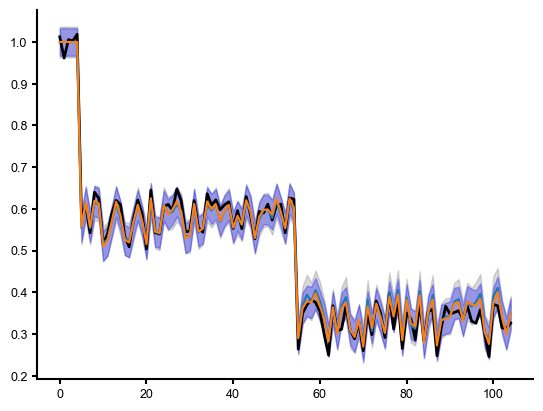

In [35]:
plt.plot(x_0, color="black", linewidth=2, label="Observation")
plt.plot(mean1_m1)
plt.fill_between(jnp.arange(len(mean1_m1)), q025_1_m1, q975_1_m1, color="gray", alpha=0.3, label="95% Credible Interval")
plt.plot(mean1_m2)
plt.fill_between(jnp.arange(len(mean1_m2)), q025_1_m2, q975_1_m2, color="blue", alpha=0.3)

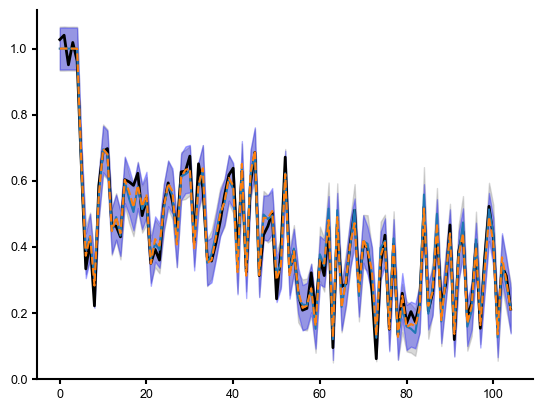

In [36]:
plt.plot(x_1, color="black", linewidth=2, label="Observation")
plt.plot(mean2_m1)
plt.fill_between(jnp.arange(len(mean2_m1)), q025_2_m1, q975_2_m1, color="gray", alpha=0.3, label="95% Credible Interval")
plt.plot(mean2_m2, '--')
plt.fill_between(jnp.arange(len(mean2_m2)), q025_2_m2, q975_2_m2, color="blue", alpha=0.3)

In [97]:
def to_fod(theta, model_mask, rng, n=100):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    return simulator.to_fod().sample(rng, (n,))


In [ ]:

samples = jax.vmap(to_fod, in_axes=(0,None,0))(thetas_post2_m1, m1, jax.random.split(jax.random.key(0), 100_000))
samples = samples.reshape(-1, samples.shape[-1])


In [ ]:

samples2 = jax.vmap(to_fod, in_axes=(0,None,0))(thetas_post2, m2, jax.random.split(jax.random.key(0), 100_000))
samples2 = samples2.reshape(-1, samples2.shape[-1])

In [40]:
def sample_model_marg_post(rng):
    rng_mask, rng_theta, rng_fod = jax.random.split(rng,3)
    mask = model.sample_mask(rng_mask, acq, x_1, jnp.array([0.5]))
    theta = model.sample_theta(rng_theta, acq, x_1, t_min=5e-3,num_steps=128, model_mask=mask)
    fod = to_fod(theta, mask, rng_fod)
    return fod, theta, mask

samples3, thetas ,masks = jax.lax.map(sample_model_marg_post,jax.random.split(jax.random.key(0), 50_000), batch_size=10_000)

In [41]:
def pred(theta, m, rng):
    sim = sim_type.from_theta(theta, model_mask=m)
    return sim.signal(acq, rng)
xs_pred3 = jax.vmap(pred)(thetas, masks, jax.random.split(jax.random.key(1), thetas.shape[0]))

In [42]:
predictive_error1 = jnp.sqrt(jnp.mean((xs_pred2_m1 - x_1)**2, axis=-1))
predictive_error2 = jnp.sqrt(jnp.mean((xs_pred2 - x_1)**2, axis=-1))
predictive_error3 = jnp.sqrt(jnp.mean((xs_pred3 - x_1)**2, axis=-1))

In [43]:
predictive_error3 = predictive_error3[~jnp.isnan(predictive_error3)]

In [44]:

def style_violin(violin, colors) -> None:
    for body, color in zip(violin["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_linewidth(0.4)
        body.set_alpha(0.7)
    if "cmins" in violin:
        violin["cmins"].set_color(color)
    if "cmaxes" in violin:
        violin["cmaxes"].set_color(color)
    for key in ("cbars", "cmeans"):
        if key in violin:
            violin[key].set_color("black")
            violin[key].set_linewidth(0.4)


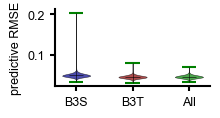

In [45]:
fig = plt.figure(figsize=(2,1))
out = plt.violinplot([predictive_error1, predictive_error2,predictive_error3], positions=[1,2,3],showmeans=True)
style_violin(out, ["darkblue", "darkred", "green"])
plt.ylabel("predictive RMSE")
plt.xticks([1,2,3],["B3S", "B3T", "All"])
fig.savefig("predictive_rmse_all_model_illustrative.png", dpi=300)
fig.savefig("predictive_rmse_all_model_illustrative.svg")

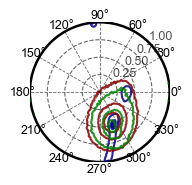

In [48]:
fig, ax = plot_stereographic_contour([samples.squeeze(), samples2.squeeze(), samples3.reshape(-1,3).squeeze()], levels=[0.025,0.25,0.5, 0.75], colors=["darkblue", "darkred", "green"], cmap=None,  frame_color="black", filled=False, bins=100, figsize=(2,2))
fig.savefig("fod_difference.png", dpi=300)
fig.savefig("fod_difference.svg")

In [54]:
import matplotlib.pyplot as plt
import numpy as np

from dipy.core.gradients import gradient_table
from dipy.data import get_fnames, get_sphere
from dipy.direction import peak_directions, peaks_from_model
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti
from dipy.reconst.csdeconv import auto_response_ssst, recursive_response
from dipy.reconst.rumba import RumbaSDModel
from dipy.segment.mask import median_otsu
from dipy.sims.voxel import single_tensor_odf
from dipy.viz import actor, window

import numpy as np
from dipy.core.sphere import disperse_charges, Sphere, HemiSphere
from dipy.data import get_sphere
from dipy.reconst.shm import sf_to_sh, sh_to_sf
from dipy.sims.voxel import multi_tensor_odf
from dipy.viz import window, actor

sphere = get_sphere(name="symmetric362")

In [7]:
gtab = gradient_table(bvals, bvecs)

/tmp/ipykernel_2545292/1123708810.py:1: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab = gradient_table(bvals, bvecs)


In [59]:
odf.shape

(362,)

In [ ]:
mevals = np.array([[0.0015, 0.00015, 0.00015],
                   [0.0015, 0.00015, 0.00015]])
angles = [(0, 0), (60, 0)]
odf = multi_tensor_odf(sphere.vertices, mevals, angles, [50, 50])

# Change this value to try out other bases
sh_basis = 'descoteaux07'
# Change this value to try other maximum orders
sh_order_max = 8

sh_coeffs = sf_to_sh(odf, sphere, sh_order_max, sh_basis)

Saving illustration as symm_signal.png


/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: UserWarning: We'll no longer accept the way you call the record function in future versions of FURY.

Here's how to call the Function record: record(scene='value', cam_pos='value', cam_focal='value', cam_view='value', out_path='value', path_numbering='value', n_frames='value', az_ang='value', magnification='value', size='value', reset_camera='value', screen_clip='value', stereo='value', verbose='value')

  exec(code_obj, self.user_global_ns, self.user_ns)


In [87]:
from sh_lib import samples_to_sh

samples = jax.random.choice(jax.random.key(0),sphere.vertices, shape=(50_000,), p=odf, replace=True, axis=0)

In [88]:
jnp.mean(jnp.abs(samples_to_sh(samples, sphere)[1] - sh_coeffs))

Array(0.02637924, dtype=float32)

In [8]:
rumba = RumbaSDModel(gtab)
print(
    f"wm_response: {rumba.wm_response}, "
    + f"csf_response: {rumba.csf_response}, "
    + f"gm_response: {rumba.gm_response}"
)

wm_response: [0.0017 0.0002 0.0002], csf_response: 0.003, gm_response: 0.0008


In [59]:
!export VTK_DEFAULT_RENDER_WINDOW_OFFSCREEN=1
!export PYOPENGL_PLATFORM=osmesa
!export MESA_GL_VERSION_OVERRIDE=3.3

/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [10]:
# Enables/disables interactive visualization
interactive = False

scene = window.Scene()

evals = rumba.wm_response
evecs = np.array([[0, 1, 0], [0, 0, 1], [1, 0, 0]]).T

response_odf = single_tensor_odf(sphere.vertices, evals=evals, evecs=evecs)
# Transform our data from 1D to 4D
response_odf = response_odf[None, None, None, :]
response_actor = actor.odf_slicer(response_odf, sphere=sphere, colormap="plasma")

scene.add(response_actor)
window.record(scene=scene, size=(200, 200), out_path="default_response.png")

if interactive:
    window.show(scene)

In [14]:
b0_mask, mask = median_otsu(data, median_radius=2, numpass=1, vol_idx=np.arange(10))

In [19]:
data.shape

(104, 104, 72, 105)

In [20]:
response, _ = auto_response_ssst(gtab, data_norm, roi_radii=10, fa_thr=0.7)
print(response)

(array([0.00141885, 0.00031058, 0.00031058]), np.float32(1.0))


In [21]:
rumba = RumbaSDModel(gtab, wm_response=response[0], gm_response=None, sphere=sphere)

In [43]:
data_small = data_norm[40:65, 55:80, 38:39]

In [44]:
rumba_fit = rumba.fit(data_small)
odf = rumba_fit.odf()

In [45]:
f_iso = rumba_fit.f_iso
f_wm = rumba_fit.f_wm

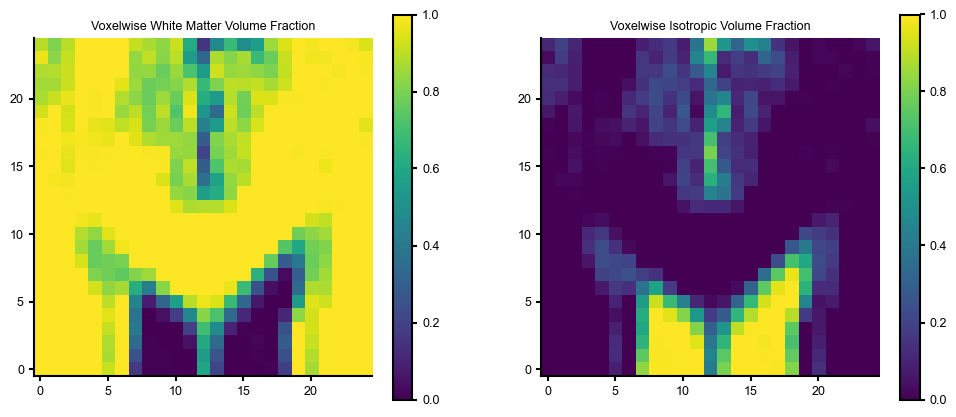

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

ax0 = axs[0].imshow(f_wm[..., 0].T, origin="lower")
axs[0].set_title("Voxelwise White Matter Volume Fraction")

ax1 = axs[1].imshow(f_iso[..., 0].T, origin="lower")
axs[1].set_title("Voxelwise Isotropic Volume Fraction")

plt.colorbar(ax0, ax=axs[0])
plt.colorbar(ax1, ax=axs[1])

In [114]:
combined.shape

(25, 25, 1, 362)

In [ ]:
combined = rumba_fit.combined_odf_iso

fodf_spheres = actor.odf_slicer(
    combined, sphere=sphere, norm=False, scale=0.5, colormap=None,
)
bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
scene.add(bg)
scene.add(fodf_spheres)
print("Saving illustration as rumba_odfs.png")
window.record(scene=scene, out_path="rumba_odfs.png", size=(1600, 1600))
if interactive:
    window.show(scene)

Saving illustration as rumba_odfs.png


In [189]:
from functools import partial
def theta_samples(model_mask, x_o):
    sample_fn = jax.jit(jax.vmap(partial(model.sample_theta, t_min=5e-3,num_steps=256, model_mask=model_mask), in_axes=(0,None, None)))
    thetas_post = sample_fn(jax.random.split(jax.random.key(0), 1_000), acq, x_o)
    return thetas_post

def theta_and_mask(x_o):
    sample_mask_fn = jax.jit(jax.vmap(partial(model.sample_mask, acq=acq, x=x_o, mask_prior=jnp.array([1.])), in_axes=(0,)))
    model_mask = sample_mask_fn(jax.random.split(jax.random.key(0), 1_000))
    sample_theta_fn = jax.jit(jax.vmap(partial(model.sample_theta, t_min=5e-3,num_steps=256), in_axes=(0,None, None)))
    thetas_post = sample_theta_fn(jax.random.split(jax.random.key(1), 1_000), acq, x_o, model_mask=model_mask)
    return thetas_post, model_mask


In [ ]:
theta_samples_per_xs = jax.vmap(theta_samples, in_axes=(None,0))(m1, data_small.reshape(-1, data_small.shape[-1]))

In [154]:
theta_samples_per_xs_B3T = jax.vmap(theta_samples, in_axes=(None,0))(m2, data_small.reshape(-1, data_small.shape[-1]))

W0110 14:47:47.242011 2545292 hlo_rematerialization.cc:3204] Can't reduce memory use below 56.42GiB (60581173939 bytes) by rematerialization; only reduced to 57.83GiB (62091534769 bytes), down from 57.88GiB (62150614825 bytes) originally


In [190]:
theta_samples_all, model_masks_all = jax.vmap(theta_and_mask, in_axes=(0,))(data_small.reshape(-1, data_small.shape[-1]))

W0110 15:19:32.584345 2545292 hlo_rematerialization.cc:3204] Can't reduce memory use below 56.41GiB (60574048939 bytes) by rematerialization; only reduced to 58.09GiB (62370908836 bytes), down from 58.19GiB (62486238940 bytes) originally


In [126]:
fods = []
fod_fn = jax.jit(jax.vmap(partial(to_fod, n=100), in_axes=(0,None,0)))
for i in range(theta_samples_per_xs.shape[0]):
    fods.append(fod_fn(theta_samples_per_xs[i], m1, jax.random.split(jax.random.key(i), 1_000)).reshape(-1, 3))

In [127]:
fods_sh = []
for fod in fods:
    fod = fod.reshape(-1, fod.shape[-1])
    fods_sh.append(samples_to_sh(fod, sphere)[0])

In [155]:
fods_sh_b3T = []
for i in range(theta_samples_per_xs_B3T.shape[0]):
    samples = fod_fn(theta_samples_per_xs_B3T[i], m2, jax.random.split(jax.random.key(i), 1_000)).reshape(-1, 3)
    fods_sh_b3T.append(samples_to_sh(samples, sphere)[0])


In [192]:
fods_sh_all = []
fod_fn = jax.jit(jax.vmap(partial(to_fod, n=100), in_axes=(0,0,0)))
for i in range(theta_samples_all.shape[0]):
    samples = fod_fn(theta_samples_all[i], model_masks_all[i], jax.random.split(jax.random.key(i), 1_000)).reshape(-1, 3)
    fods_sh_all.append(samples_to_sh(samples, sphere)[0])

In [133]:
fods_b3s = jnp.array(fods_sh).reshape(25,25, 1, 362)

In [156]:
fods_b3T = jnp.array(fods_sh_b3T).reshape(25,25, 1, 362)

In [194]:
fods_all = jnp.array(fods_sh_all).reshape(25,25, 1, 362)

In [ ]:
np.save("fods_b3s_all_model_illustrative.npy", fods_b3s)
np.save("fods_b3T_all_model_illustrative.npy", fods_b3T)
np.save("fods_all_all_model_illustrative.npy", fods_all)
np.save("fods_rumba_model_illustrative.npy", combined)
np.save("fods_iso.npy", f_iso)

: 

In [ ]:
# KL divergence between two spherical pmfs
def kl_div(p, q):
    p = p / jnp.sum(p)
    q = q / jnp.sum(q)
    return jnp.sum(jnp.where(p != 0, p * jnp.log(p / q), 0.0))


Array(0.4334671, dtype=float32)

In [197]:
ksds_ruba_b3T = jax.vmap(jax.vmap(jax.vmap(kl_div)))(combined, fods_b3T)

In [198]:
ksds_ruba_b3S = jax.vmap(jax.vmap(jax.vmap(kl_div)))(combined, fods_b3s)

In [207]:
ksds_ruba_all = jax.vmap(jax.vmap(jax.vmap(kl_div)))(combined, fods_all)

In [203]:
ksds_b3S_b3T = jax.vmap(jax.vmap(jax.vmap(kl_div)))(fods_b3s, fods_b3T)

In [209]:
ksds_b3S_all = jax.vmap(jax.vmap(jax.vmap(kl_div)))(fods_b3s, fods_all)

In [210]:
ksds_ruba_b3T.mean(), ksds_ruba_b3S.mean(), ksds_ruba_all.mean(), ksds_b3S_b3T.mean(), ksds_b3S_all.mean()

(Array(0.4334671, dtype=float32),
 Array(0.447266, dtype=float32),
 Array(0.38180974, dtype=float32),
 Array(0.33068374, dtype=float32),
 Array(0.2188475, dtype=float32))

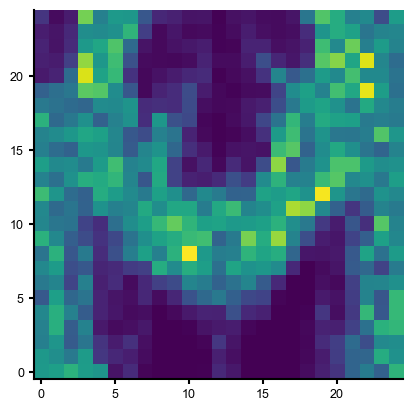

In [205]:
plt.imshow(ksds_b3S_b3T[...,0].T, origin="lower")

In [ ]:
fodf_spheres = actor.odf_slicer(
    fods_b3s, sphere=sphere, norm=False, scale=0.5, colormap=None
)
bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
scene.add(bg)
scene.add(fodf_spheres)
print("Saving illustration as b3s_odfs.png")
window.record(scene=scene, out_path="b3s_odfs.png", size=(1600, 1600))
if interactive:
    window.show(scene)

Saving illustration as b3s_odfs.png


In [157]:
fodf_spheres = actor.odf_slicer(
    fods_b3T, sphere=sphere, norm=False, scale=0.5, colormap=None
)
bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
scene.add(bg)
scene.add(fodf_spheres)
print("Saving illustration as b3T_odfs.png")
window.record(scene=scene, out_path="b3T_odfs.png", size=(1600, 1600))
if interactive:
    window.show(scene)

Saving illustration as b3T_odfs.png


In [195]:
fodf_spheres = actor.odf_slicer(
    fods_all, sphere=sphere, norm=False, scale=0.5, colormap=None
)
bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
scene.add(bg)
scene.add(fodf_spheres)
print("Saving illustration as all_odfs.png")
window.record(scene=scene, out_path="all_odfs.png", size=(1600, 1600))
if interactive:
    window.show(scene)

Saving illustration as all_odfs.png


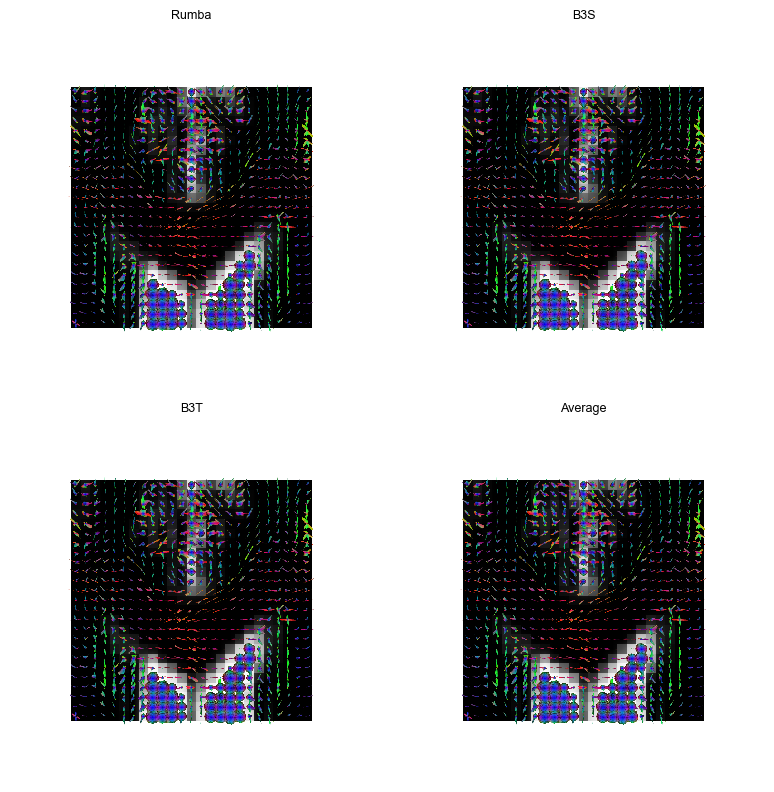

In [196]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("rumba_odfs.png")
img_b3s = Image.open("b3s_odfs.png")
img_b3T = Image.open("b3T_odfs.png")
img_all = Image.open("all_odfs.png")
fig, axes = plt.subplots(2,2, figsize=(8,8))

axes[0,0].imshow(img)
axes[0,1].imshow(img_b3s)
axes[1,0].imshow(img_b3T)
axes[1,1].imshow(img_all)
axes[0,0].axis("off")
axes[0,1].axis("off")
axes[1,0].axis("off")
axes[1,1].axis("off")
axes[0,0].set_title("Rumba")
axes[0,1].set_title("B3S")
axes[1,0].set_title("B3T")
axes[1,1].set_title("Average")

fig.tight_layout()


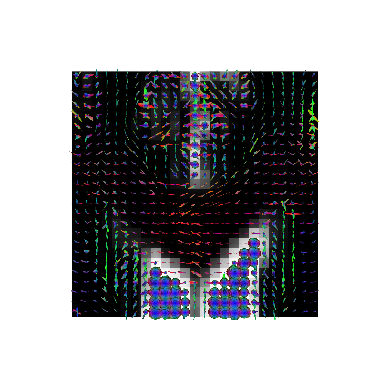

In [153]:

img = Image.open("b3s_odfs.png")
plt.imshow(img)
plt.axis("off")
plt.show()